In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from datetime import datetime
from datetime import timedelta




In [2]:
cleaned = pd.read_csv('project_dataset/project_clean_master.csv')
display(cleaned)

,user_id,id,created_at,recovery_status,cash_request_id,category,total_amount
0,9489.0,2145,2020-05-23 20:58:55.129432+00:00,completed,NaN,No Fee,0.0
1,778.0,1794,2020-05-14 21:11:47.393326+00:00,completed,NaN,No Fee,0.0
2,8218.0,2122,2020-05-22 12:47:42.741369+00:00,Normal Payment,NaN,No Fee,0.0
3,9068.0,1629,2020-05-08 11:02:44.881355+00:00,Normal Payment,NaN,No Fee,0.0
4,21465.0,23534,2020-10-23 15:20:26.163927+00:00,Normal Payment,23534.0,No Fee,5.0
...,...,...,...,...,...,...,...
22284,13681.0,20616,2020-10-12 13:54:11.686225+00:00,Normal Payment,20616.0,No Fee,5.0
22285,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0
22286,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0
22287,64517.0,20256,2020-10-10 05:40:55.700422+00:00,Normal Payment,20256.0,No Fee,5.0


In [3]:
# convert to datetime to be recognizable by pandas as time
cleaned['created_at'] = pd.to_datetime(cleaned['created_at'])
# initiate the cohort series
cohort = cleaned.groupby('user_id')['created_at'].min().dt.to_period('M')
display(cohort)
type(cohort)

C:\Users\gabyt\AppData\Local\Temp\ipykernel_2476\994425164.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohort = cleaned.groupby('user_id')['created_at'].min().dt.to_period('M')


user_id
47.0        2020-04
52.0        2019-12
53.0        2019-12
66.0        2020-04
68.0        2019-12
             ...   
103425.0    2020-11
103437.0    2020-11
103496.0    2020-11
103503.0    2020-11
103719.0    2020-11
Name: created_at, Length: 9030, dtype: period[M]

pandas.core.series.Series

In [4]:
# initiate the cohort month column by linking the cohort series based on the user id
cleaned['cohort_month'] = cleaned['user_id'].map(cohort)
display(cleaned)

,user_id,id,created_at,recovery_status,cash_request_id,category,total_amount,cohort_month
0,9489.0,2145,2020-05-23 20:58:55.129432+00:00,completed,NaN,No Fee,0.0,2020-05
1,778.0,1794,2020-05-14 21:11:47.393326+00:00,completed,NaN,No Fee,0.0,2019-12
2,8218.0,2122,2020-05-22 12:47:42.741369+00:00,Normal Payment,NaN,No Fee,0.0,2020-04
3,9068.0,1629,2020-05-08 11:02:44.881355+00:00,Normal Payment,NaN,No Fee,0.0,2020-05
4,21465.0,23534,2020-10-23 15:20:26.163927+00:00,Normal Payment,23534.0,No Fee,5.0,2020-10
...,...,...,...,...,...,...,...,...
22284,13681.0,20616,2020-10-12 13:54:11.686225+00:00,Normal Payment,20616.0,No Fee,5.0,2020-06
22285,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0,2020-10
22286,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0,2020-10
22287,64517.0,20256,2020-10-10 05:40:55.700422+00:00,Normal Payment,20256.0,No Fee,5.0,2020-10


In [5]:
# initiate the activity month column based on the created at column ordered by months
cleaned['activity_month'] = cleaned['created_at'].dt.to_period('M')
display(cleaned)

C:\Users\gabyt\AppData\Local\Temp\ipykernel_2476\2690523027.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cleaned['activity_month'] = cleaned['created_at'].dt.to_period('M')


,user_id,id,created_at,recovery_status,cash_request_id,category,total_amount,cohort_month,activity_month
0,9489.0,2145,2020-05-23 20:58:55.129432+00:00,completed,NaN,No Fee,0.0,2020-05,2020-05
1,778.0,1794,2020-05-14 21:11:47.393326+00:00,completed,NaN,No Fee,0.0,2019-12,2020-05
2,8218.0,2122,2020-05-22 12:47:42.741369+00:00,Normal Payment,NaN,No Fee,0.0,2020-04,2020-05
3,9068.0,1629,2020-05-08 11:02:44.881355+00:00,Normal Payment,NaN,No Fee,0.0,2020-05,2020-05
4,21465.0,23534,2020-10-23 15:20:26.163927+00:00,Normal Payment,23534.0,No Fee,5.0,2020-10,2020-10
...,...,...,...,...,...,...,...,...,...
22284,13681.0,20616,2020-10-12 13:54:11.686225+00:00,Normal Payment,20616.0,No Fee,5.0,2020-06,2020-10
22285,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0,2020-10,2020-10
22286,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0,2020-10,2020-10
22287,64517.0,20256,2020-10-10 05:40:55.700422+00:00,Normal Payment,20256.0,No Fee,5.0,2020-10,2020-10


In [6]:
# initiate cohort index column to establish a monthly timeline for each raw starting from the month 0
from operator import attrgetter
cleaned['cohort_index'] = (cleaned['activity_month'] - cleaned['cohort_month']).apply(attrgetter('n'))
display(cleaned)


,user_id,id,created_at,recovery_status,cash_request_id,category,total_amount,cohort_month,activity_month,cohort_index
0,9489.0,2145,2020-05-23 20:58:55.129432+00:00,completed,NaN,No Fee,0.0,2020-05,2020-05,0
1,778.0,1794,2020-05-14 21:11:47.393326+00:00,completed,NaN,No Fee,0.0,2019-12,2020-05,5
2,8218.0,2122,2020-05-22 12:47:42.741369+00:00,Normal Payment,NaN,No Fee,0.0,2020-04,2020-05,1
3,9068.0,1629,2020-05-08 11:02:44.881355+00:00,Normal Payment,NaN,No Fee,0.0,2020-05,2020-05,0
4,21465.0,23534,2020-10-23 15:20:26.163927+00:00,Normal Payment,23534.0,No Fee,5.0,2020-10,2020-10,0
...,...,...,...,...,...,...,...,...,...,...
22284,13681.0,20616,2020-10-12 13:54:11.686225+00:00,Normal Payment,20616.0,No Fee,5.0,2020-06,2020-10,4
22285,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0,2020-10,2020-10,0
22286,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0,2020-10,2020-10,0
22287,64517.0,20256,2020-10-10 05:40:55.700422+00:00,Normal Payment,20256.0,No Fee,5.0,2020-10,2020-10,0


In [7]:
# counting the usage per cohort across the timeline of measurement
grouped = cleaned.groupby(['cohort_month', 'cohort_index'])['id'].count()
display(grouped)

cohort_month  cohort_index
2019-12       0                127
              1                 41
              2                 27
              3                 41
              4                 40
                              ... 
2020-09       1                630
              2                 15
2020-10       0               5900
              1                 14
2020-11       0                 75
Name: id, Length: 74, dtype: int64

In [8]:
# the second metrics#
# # initiate the incident boolen colmun 
cleaned['incident_request'] = (cleaned['category'] == 'month_delay_on_payment').astype(int)

In [9]:
# new data frame summing the incidents per cohort
incident_counts = (cleaned.groupby(['cohort_month', 'cohort_index'])['incident_request'].sum().reset_index())
display(incident_counts)

,cohort_month,cohort_index,incident_request
0,2019-12,0,0
1,2019-12,1,0
2,2019-12,2,0
3,2019-12,3,0
4,2019-12,4,0
...,...,...,...
69,2020-09,1,0
70,2020-09,2,0
71,2020-10,0,0
72,2020-10,1,0


In [10]:
# new data frame counting the incidents per cohort
total_requests = (cleaned.groupby(['cohort_month', 'cohort_index'])['id'].count().reset_index().rename(columns={'id': 'total_requests'}))
display(total_requests)

,cohort_month,cohort_index,total_requests
0,2019-12,0,127
1,2019-12,1,41
2,2019-12,2,27
3,2019-12,3,41
4,2019-12,4,40
...,...,...,...
69,2020-09,1,630
70,2020-09,2,15
71,2020-10,0,5900
72,2020-10,1,14


In [11]:
# merging on left to include the nan valuse and change them to 0 
cohort_metrics = total_requests.merge(incident_counts, on=['cohort_month', 'cohort_index'], how='left')
cohort_metrics['incident_request'] = (cohort_metrics['incident_request'] .fillna(0) .astype(int))

In [12]:
#computing
cohort_metrics['incident_rate'] = (cohort_metrics['incident_request'] / cohort_metrics['total_requests'])
display(cohort_metrics)
# cohort_metrics.sample(20)

,cohort_month,cohort_index,total_requests,incident_request,incident_rate
0,2019-12,0,127,0,0.0
1,2019-12,1,41,0,0.0
2,2019-12,2,27,0,0.0
3,2019-12,3,41,0,0.0
4,2019-12,4,40,0,0.0
...,...,...,...,...,...
69,2020-09,1,630,0,0.0
70,2020-09,2,15,0,0.0
71,2020-10,0,5900,0,0.0
72,2020-10,1,14,0,0.0


#### Metric: Revenue generated by the Cohort

In [13]:
# normal display
cleaned

,user_id,id,created_at,recovery_status,cash_request_id,category,total_amount,cohort_month,activity_month,cohort_index,incident_request
0,9489.0,2145,2020-05-23 20:58:55.129432+00:00,completed,NaN,No Fee,0.0,2020-05,2020-05,0,0
1,778.0,1794,2020-05-14 21:11:47.393326+00:00,completed,NaN,No Fee,0.0,2019-12,2020-05,5,0
2,8218.0,2122,2020-05-22 12:47:42.741369+00:00,Normal Payment,NaN,No Fee,0.0,2020-04,2020-05,1,0
3,9068.0,1629,2020-05-08 11:02:44.881355+00:00,Normal Payment,NaN,No Fee,0.0,2020-05,2020-05,0,0
4,21465.0,23534,2020-10-23 15:20:26.163927+00:00,Normal Payment,23534.0,No Fee,5.0,2020-10,2020-10,0,0
...,...,...,...,...,...,...,...,...,...,...,...
22284,13681.0,20616,2020-10-12 13:54:11.686225+00:00,Normal Payment,20616.0,No Fee,5.0,2020-06,2020-10,4,0
22285,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0,2020-10,2020-10,0,0
22286,82122.0,22357,2020-10-20 07:58:04.006937+00:00,Normal Payment,22357.0,No Fee,5.0,2020-10,2020-10,0,0
22287,64517.0,20256,2020-10-10 05:40:55.700422+00:00,Normal Payment,20256.0,No Fee,5.0,2020-10,2020-10,0,0


##### Reminder: "You might see the same Loan ID appear twice in the list. This is NOT a mistake. It just means that specific loan had two different fees (for example, a service fee AND a delay fee)."
##### so one ID can have multiple Fees, we edit to: for one ID, we add up the "total_amount" and call it "request_revenue" (one row = one request)

In [14]:
revenue = (
    cleaned.groupby(["id", "user_id", "cohort_month", "activity_month", "cohort_index"], as_index=False)
           .agg(request_revenue=("total_amount", "sum"))
)
revenue

,id,user_id,cohort_month,activity_month,cohort_index,request_revenue
0,9,430.0,2019-12,2019-12,0,0.0
1,11,735.0,2019-12,2019-12,0,0.0
2,28,140.0,2019-12,2019-12,0,0.0
3,34,1145.0,2019-12,2019-12,0,0.0
4,48,816.0,2019-12,2019-12,0,0.0
...,...,...,...,...,...,...
15737,27005,103719.0,2020-11,2020-11,0,0.0
15738,27006,55916.0,2020-09,2020-11,2,5.0
15739,27007,39339.0,2020-09,2020-11,2,5.0
15740,27009,100781.0,2020-11,2020-11,0,5.0


##### now summarize revenue each cohort

In [15]:
revenue_by_cohort = (
    revenue.groupby(["cohort_month", "cohort_index"], as_index=False)
             .agg(cohort_revenue=("request_revenue", "sum"))
)
revenue_by_cohort.sample(20)

,cohort_month,cohort_index,cohort_revenue
39,2020-04,0,0.0
59,2020-07,0,4825.0
25,2020-02,3,75.0
68,2020-09,0,11235.0
64,2020-08,0,4485.0
43,2020-04,4,580.0
5,2019-12,5,45.0
28,2020-02,6,310.0
22,2020-02,0,0.0
32,2020-03,1,0.0


Retention rate new metric

In [16]:
user_request_counts = cleaned.groupby("user_id")["id"].nunique()
second_time_users = user_request_counts[user_request_counts >= 2].index
cleaned["second_time_user"] = cleaned["user_id"].isin(second_time_users).astype(int)

cohort_users = cleaned[["cohort_month", "user_id", "second_time_user"]].drop_duplicates()
retention_by_cohort = (
    cohort_users.groupby("cohort_month", as_index=False)
               .agg(total_users=("user_id", "nunique"), retained_users=("second_time_user", "sum"))
)
retention_by_cohort["retention_rate"] = round(retention_by_cohort["retained_users"] / retention_by_cohort["total_users"], 2)
retention_by_cohort.head()


,cohort_month,total_users,retained_users,retention_rate
0,2019-12,122,89,0.73
1,2020-01,43,33,0.77
2,2020-02,62,53,0.85
3,2020-03,62,49,0.79
4,2020-04,157,118,0.75


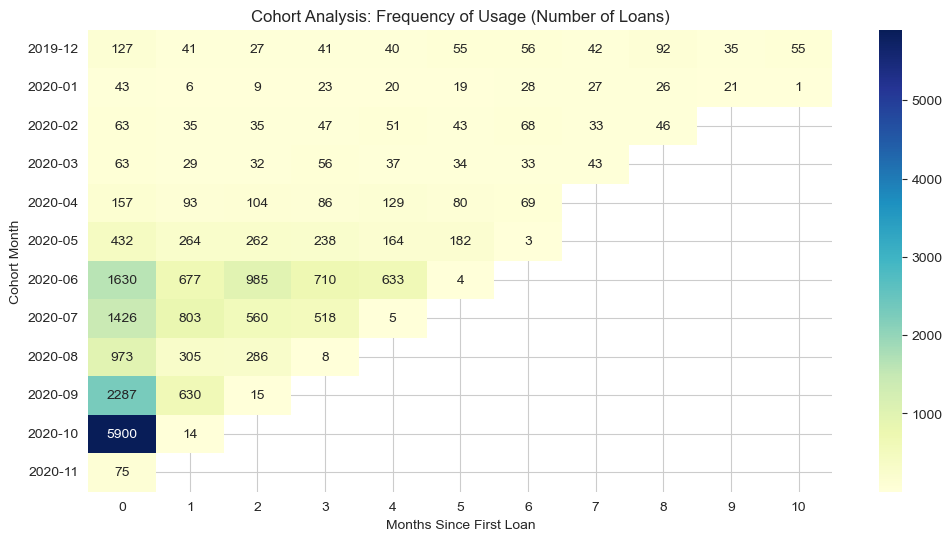

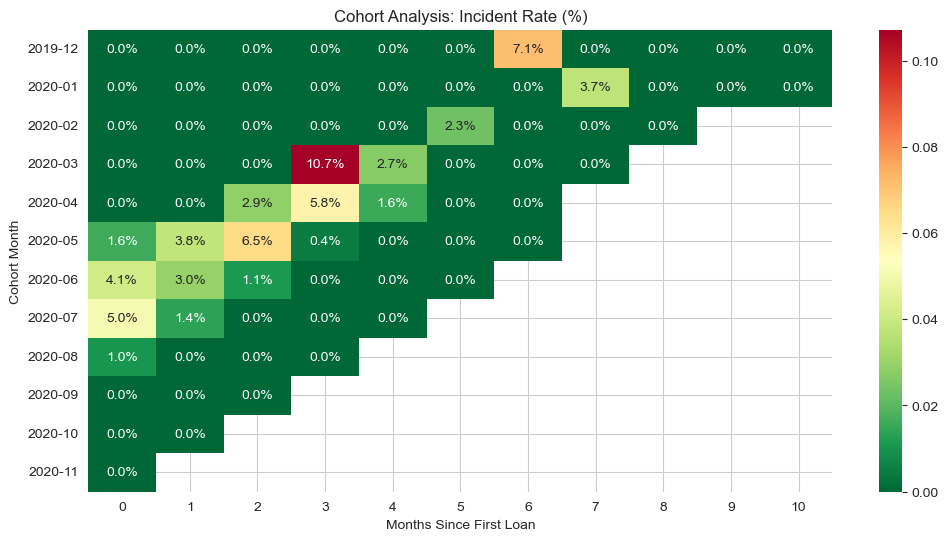

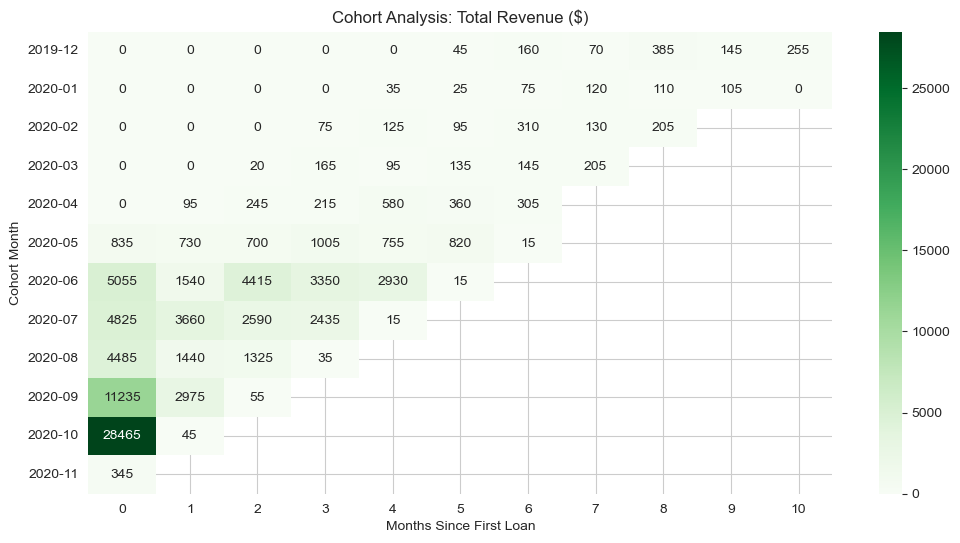

C:\Users\gabyt\AppData\Local\Temp\ipykernel_2476\3181829728.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=retention_rate_df, x='cohort_month', y='second_time_user', palette='Blues_d')


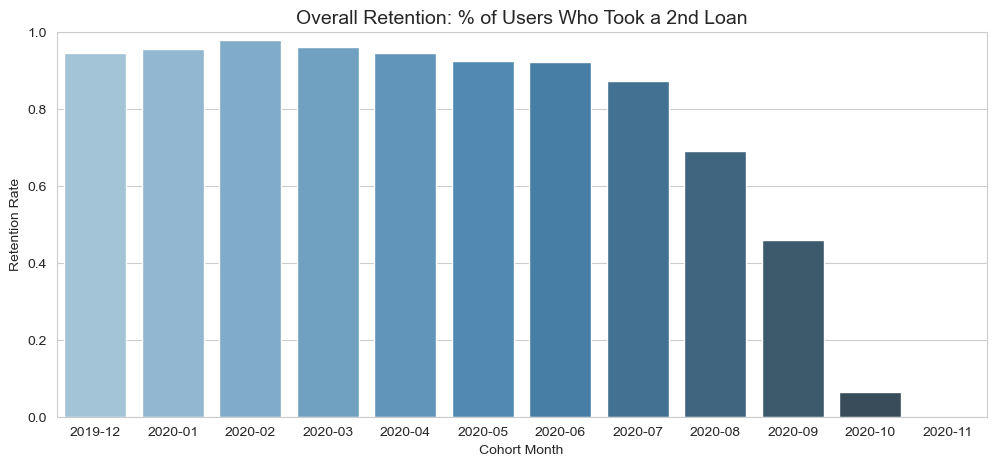

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


usage_pivot = cleaned.pivot_table(index='cohort_month', columns='cohort_index', values='id', aggfunc='count')

incident_pivot = cleaned.pivot_table(index='cohort_month', columns='cohort_index', values='incident_request', aggfunc='mean')

revenue_pivot = cleaned.pivot_table(index='cohort_month', columns='cohort_index', values='total_amount', aggfunc='sum')

user_request_counts = cleaned.groupby("user_id")["id"].nunique()
second_timers = user_request_counts[user_request_counts >= 2].index
cleaned["second_time_user"] = cleaned["user_id"].isin(second_timers).astype(int)
retention_rate_df = cleaned.groupby("cohort_month")["second_time_user"].mean().reset_index()


sns.set_style("whitegrid")

# Chart 1: Usage Heatmap
plt.figure(figsize=(12, 6))
plt.title('Cohort Analysis: Frequency of Usage (Number of Loans)')
sns.heatmap(usage_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Loan')
plt.show()

# Chart 2: Incident Rate Heatmap
plt.figure(figsize=(12, 6))
plt.title('Cohort Analysis: Incident Rate (%)')
sns.heatmap(incident_pivot, annot=True, fmt='.1%', cmap='RdYlGn_r') # Red = Bad
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Loan')
plt.show()

# Chart 3: Revenue Heatmap
plt.figure(figsize=(12, 6))
plt.title('Cohort Analysis: Total Revenue ($)')
sns.heatmap(revenue_pivot, annot=True, fmt='.0f', cmap='Greens')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Loan')
plt.show()

# Chart 4: Overall Retention Rate per Cohort
plt.figure(figsize=(12, 5))
sns.barplot(data=retention_rate_df, x='cohort_month', y='second_time_user', palette='Blues_d')
plt.title('Overall Retention: % of Users Who Took a 2nd Loan', fontsize=14)
plt.ylabel('Retention Rate')
plt.xlabel('Cohort Month')
plt.ylim(0, 1) 
plt.show()